# **01 - Naive baselines for Jeonse and Wolse**

Reference models that every later model must beat. Each baseline is fit on TRAIN only (2022-01-01..2024-12-31) and evaluated on TEST (2025), per track. Predictions are in original wones (units of 10,000 KRW).

| model_id | Prediction |
|---|---|
| `baseline_global_median` | TRAIN median of the target |
| `baseline_district` | TRAIN median by `district_name` |
| `baseline_district_type` | median by district x `building_type`; fallback: district, then global |
| `baseline_district_type_area` | median by district x type x area quintile (TRAIN quintiles); fallback: district x type, district, global |
| `baseline_drift` | `baseline_district_type` x (2024 median / TRAIN median) |

Primary metric: WAPE. The drift baseline is a naive time-aware reference.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.baselines import BASELINES
from rent_model.data import load_clean
from rent_model.features import select_track
from rent_model.io import save_run
from rent_model.metrics import wape, all_metrics
from rent_model.splits import temporal_split

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 100

## Fit, predict and save runs

In [2]:
df = load_clean()
data, runs, rows = {}, {}, []
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    target = spec['target']
    data[track] = (train, test, target)
    for cls in BASELINES:
        model = cls().fit(train, target)
        pred = model.predict(test)
        runs[(track, model.model_id)] = pred
        if hasattr(model, 'ratio_'):
            print(f"{track}: drift ratio (2024 median / TRAIN median) = {model.ratio_:.4f}")
        meta = {'fit_rows': len(train), 'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        save_run(track, model.model_id, test[target], pred, meta=meta,
                 context=test[['district_name', 'contract_date']])
        rows.append({'track': track, 'model_id': model.model_id,
                     **all_metrics(test[target].to_numpy(), pred)})
metrics = pd.DataFrame(rows)
print({t: (len(v[0]), len(v[1])) for t, v in data.items()}, '(train rows, test rows)')

jeonse: drift ratio (2024 median / TRAIN median) = 1.0745


wolse: drift ratio (2024 median / TRAIN median) = 1.0577
{'jeonse': (138848, 37935), 'wolse': (152714, 57829)} (train rows, test rows)


## Jeonse (target: deposit)

### Metrics on TEST

In [3]:
cols = ['model_id', 'n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
metrics_jeonse = metrics[metrics['track'] == 'jeonse'][cols].set_index('model_id')
display(metrics_jeonse)

,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
baseline_global_median,37935,55.56,"25,041.04",49.01,-20.14,-37.10,0.78,-0.07
baseline_district,37935,51.69,"23,298.27",46.50,-16.67,-29.72,0.71,0.11
baseline_district_type,37935,34.47,"15,535.31",26.32,-6.38,-14.45,0.49,0.59
baseline_district_type_area,37935,27.25,"12,282.26",20.38,-4.76,-10.29,0.39,0.73
baseline_drift,37935,33.87,"15,264.52",26.15,0.59,-8.08,0.49,0.58


**Interpretation.** Adding building type to the district median lowers WAPE from 51.69% (`baseline_district`) to 34.47% (`baseline_district_type`), and adding the area quintile lowers it again to 27.25% (`baseline_district_type_area`), the best Jeonse baseline, with the highest `r2_log` (0.73). The global median has a median bias of -20.14% and an aggregate bias of -37.10%: 2025 deposits are higher than the TRAIN median. The drift correction removes most of the median bias of `baseline_district_type` (-6.38% to 0.59%) and reduces its WAPE only slightly (34.47% to 33.87%), so the level shift explains a small part of the error; the dominant error is cross-sectional (type and size).

### Error by building_type (WAPE, %)

In [4]:
train, test, target = data['jeonse']
by_type = pd.DataFrame({
    mid: test.assign(pred=runs[('jeonse', mid)]).groupby('building_type').apply(
        lambda g: wape(g[target], g['pred']), include_groups=False)
    for mid in metrics_jeonse.index})
by_type.insert(0, 'n_test', test['building_type'].value_counts().astype(int))
display(by_type)

,n_test,baseline_global_median,baseline_district,baseline_district_type,baseline_district_type_area,baseline_drift
building_type,,,,,,
Apartment,22645,56.97,50.91,35.07,27.51,34.27
Detached / Multi-household house,3977,102.07,104.46,41.11,33.05,41.25
Officetel,3369,37.40,42.49,31.96,21.17,31.12
Row house / Villa (multi-unit),7944,39.14,45.18,29.18,26.28,29.88


**Interpretation.** Building type is the main source of the improvement: for `baseline_district` the WAPE of Apartment is 50.91% and of Detached / Multi-household house is 104.46%, while `baseline_district_type` gives 35.07% and 41.11%. With the area quintile, Officetel reaches 21.17% and Apartment 27.51%. Detached / Multi-household house remains the hardest type (33.05%).

### Error by district (top and bottom five by WAPE, best district-aware baseline)

In [5]:
best_id = metrics_jeonse['wape_pct'].idxmin()
by_district = test.assign(pred=runs[('jeonse', best_id)]).groupby('district_name').apply(
    lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred'])}), include_groups=False
).sort_values('wape_pct').astype({'n_test': int})
print('Baseline shown:', best_id)
print('Lowest WAPE (five best districts)'); display(by_district.head(5))
print('Highest WAPE (five worst districts)'); display(by_district.tail(5).iloc[::-1])

Baseline shown: baseline_district_type_area
Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Nowon-gu,1908,19.72
Dongdaemun-gu,1463,20.00
Seongbuk-gu,1347,20.08
Jung-gu,598,20.42
Gangbuk-gu,597,21.74


Highest WAPE (five worst districts)


,n_test,wape_pct
district_name,,
Seocho-gu,2272,37.51
Gangnam-gu,2634,32.62
Yongsan-gu,1228,32.31
Jongno-gu,368,31.96
Gangdong-gu,2252,30.59


**Interpretation.** Even the best baseline varies by district: from 19.72% (Nowon-gu) to 37.51% (Seocho-gu). The worst districts (Seocho-gu, Gangnam-gu, Yongsan-gu, Jongno-gu, Gangdong-gu) have WAPE between 30.59% and 37.51%, so a district x type x area median does not capture the within-cell price dispersion of the high-price districts.

### Calibration: predicted vs actual median by quarter of 2025

,actual,baseline_global_median,baseline_district,baseline_district_type,baseline_district_type_area,baseline_drift
quarter,,,,,,
1,"35,000.00","28,350.00","30,000.00","37,000.00","36,750.00","39,757.05"
2,"34,500.00","28,350.00","30,000.00","35,000.00","35,000.00","37,608.02"
3,"36,500.00","28,350.00","30,000.00","35,000.00","35,000.00","37,608.02"
4,"38,825.00","28,350.00","30,000.00","37,000.00","38,500.00","39,757.05"


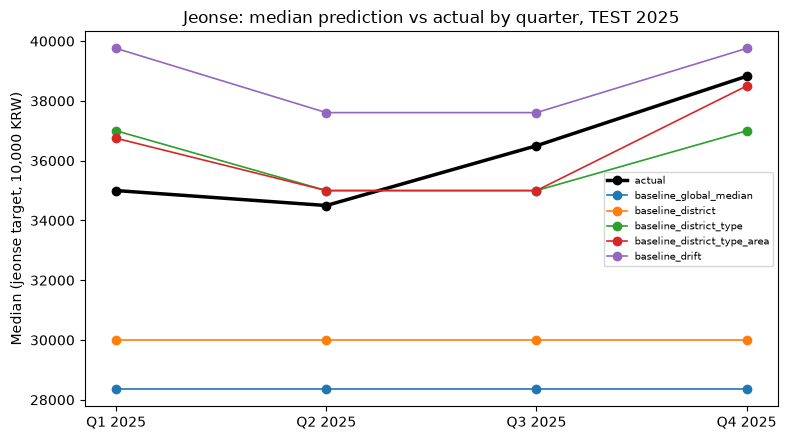

In [6]:
quarter = test['contract_date'].dt.quarter.rename('quarter')
actual_q = test.groupby(quarter)[target].median()
calib = pd.DataFrame({'actual': actual_q})
for mid in metrics_jeonse.index:
    calib[mid] = pd.Series(runs[('jeonse', mid)], index=test.index).groupby(quarter).median()
display(calib)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(calib.index, calib['actual'], color='black', marker='o', lw=2.5, label='actual')
for mid in metrics_jeonse.index:
    ax.plot(calib.index, calib[mid], marker='o', lw=1.2, label=mid)
ax.set_xticks(calib.index, [f'Q{q} 2025' for q in calib.index])
ax.set_ylabel('Median (jeonse target, 10,000 KRW)')
ax.set_title('Jeonse: median prediction vs actual by quarter, TEST 2025')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

**Interpretation.** The actual quarterly median rises from 35,000 (Q1) to 38,825 (Q4). The district-only and global baselines are flat (30,000 and 28,350) and sit below the actual value in every quarter. `baseline_district_type_area` tracks the level closely (36,750, 35,000, 35,000, 38,500), but its quarterly pattern comes only from the 2025 mix of building types and areas, since the model has no time component. `baseline_drift` is above the actual median in every quarter (39,757, 37,608, 37,608 and 39,757 against 35,000, 34,500, 36,500 and 38,825).

## Wolse (target: monthly rent)

### Metrics on TEST

In [7]:
cols = ['model_id', 'n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
metrics_wolse = metrics[metrics['track'] == 'wolse'][cols].set_index('model_id')
display(metrics_wolse)

,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,
baseline_global_median,57829,56.55,42.39,40.91,-5.45,-30.63,0.86,-0.00
baseline_district,57829,54.76,41.05,39.39,-7.69,-27.48,0.83,0.06
baseline_district_type,57829,51.93,38.93,35.59,-6.25,-19.53,0.81,0.10
baseline_district_type_area,57829,46.96,35.20,32.53,-7.41,-14.58,0.76,0.21
baseline_drift,57829,51.73,38.78,35.29,-0.84,-14.89,0.82,0.08


**Interpretation.** Wolse is harder to predict from these keys: the best WAPE is 46.96% (`baseline_district_type_area`), against 56.55% for the global median, and `r2_log` stays at 0.21 at most. The gain from district alone is small (54.76%) and building type adds less than in Jeonse (51.93%). Aggregate bias remains negative for every baseline (from -14.58% to -30.63%), and `baseline_drift` has the median bias closest to zero (-0.84%) with an aggregate bias of -14.89%.

### Error by building_type (WAPE, %)

In [8]:
train, test, target = data['wolse']
by_type = pd.DataFrame({
    mid: test.assign(pred=runs[('wolse', mid)]).groupby('building_type').apply(
        lambda g: wape(g[target], g['pred']), include_groups=False)
    for mid in metrics_wolse.index})
by_type.insert(0, 'n_test', test['building_type'].value_counts().astype(int))
display(by_type)

,n_test,baseline_global_median,baseline_district,baseline_district_type,baseline_district_type_area,baseline_drift
building_type,,,,,,
Apartment,17911,69.95,67.33,62.79,53.81,62.55
Detached / Multi-household house,17711,33.68,32.67,32.25,31.08,31.88
Officetel,10300,49.99,48.71,45.36,42.77,45.22
Row house / Villa (multi-unit),11907,54.44,53.59,53.13,52.63,53.17


**Interpretation.** Apartment and Officetel gain most from the area quintile (Apartment 62.79% to 53.81%, Officetel 45.36% to 42.77% relative to `baseline_district_type`). Detached / Multi-household house has the lowest error across all baselines (31.08% with area) and almost no gain from type or area information (32.67% for `baseline_district`).

### Error by district (top and bottom five by WAPE, best district-aware baseline)

In [9]:
best_id = metrics_wolse['wape_pct'].idxmin()
by_district = test.assign(pred=runs[('wolse', best_id)]).groupby('district_name').apply(
    lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred'])}), include_groups=False
).sort_values('wape_pct').astype({'n_test': int})
print('Baseline shown:', best_id)
print('Lowest WAPE (five best districts)'); display(by_district.head(5))
print('Highest WAPE (five worst districts)'); display(by_district.tail(5).iloc[::-1])

Baseline shown: baseline_district_type_area
Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Dobong-gu,977,32.62
Gangbuk-gu,1157,34.41
Gwanak-gu,3924,35.11
Nowon-gu,1885,38.38
Dongjak-gu,2451,39.02


Highest WAPE (five worst districts)


,n_test,wape_pct
district_name,,
Seocho-gu,2686,57.61
Yongsan-gu,1233,54.73
Songpa-gu,4660,53.28
Gangnam-gu,3643,52.07
Gangdong-gu,3092,50.37


**Interpretation.** WAPE of the best baseline ranges from 32.62% (Dobong-gu) to 57.61% (Seocho-gu). The five worst districts (Seocho-gu, Yongsan-gu, Songpa-gu, Gangnam-gu, Gangdong-gu) have WAPE between 50.37% and 57.61%, with between 1,233 and 4,660 test rows each.

### Calibration: predicted vs actual median by quarter of 2025

,actual,baseline_global_median,baseline_district,baseline_district_type,baseline_district_type_area,baseline_drift
quarter,,,,,,
1,55.00,52.00,50.00,50.00,50.00,52.88
2,55.00,52.00,50.00,50.00,50.00,52.88
3,58.00,52.00,50.00,50.00,50.00,52.88
4,57.00,52.00,50.00,50.00,50.00,52.88


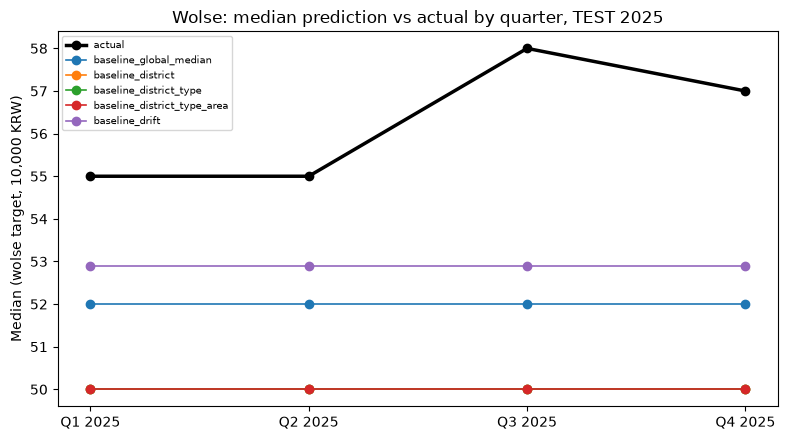

In [10]:
quarter = test['contract_date'].dt.quarter.rename('quarter')
actual_q = test.groupby(quarter)[target].median()
calib = pd.DataFrame({'actual': actual_q})
for mid in metrics_wolse.index:
    calib[mid] = pd.Series(runs[('wolse', mid)], index=test.index).groupby(quarter).median()
display(calib)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(calib.index, calib['actual'], color='black', marker='o', lw=2.5, label='actual')
for mid in metrics_wolse.index:
    ax.plot(calib.index, calib[mid], marker='o', lw=1.2, label=mid)
ax.set_xticks(calib.index, [f'Q{q} 2025' for q in calib.index])
ax.set_ylabel('Median (wolse target, 10,000 KRW)')
ax.set_title('Wolse: median prediction vs actual by quarter, TEST 2025')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

**Interpretation.** The actual quarterly median is 55, 55, 58 and 57 (10,000 KRW). The district-based baselines predict a flat median of 50 and the global median 52; `baseline_drift` predicts 52.88 in every quarter. No baseline reproduces the Q3-Q4 increase, which is expected because none of them has a time component beyond the single drift factor.

## Summary

In [11]:
summary = metrics.pivot(index='model_id', columns='track', values='wape_pct')
summary = summary.loc[[c().model_id for c in BASELINES]]
display(summary)
for track in config.TRACKS:
    print(f"Bar to beat ({track}): {summary[track].idxmin()} with WAPE {summary[track].min():.2f}%")

track,jeonse,wolse
model_id,,
baseline_global_median,55.56,56.55
baseline_district,51.69,54.76
baseline_district_type,34.47,51.93
baseline_district_type_area,27.25,46.96
baseline_drift,33.87,51.73


Bar to beat (jeonse): baseline_district_type_area with WAPE 27.25%
Bar to beat (wolse): baseline_district_type_area with WAPE 46.96%


## Conclusion

`baseline_district_type_area` has the lowest WAPE in both tracks (27.25% for Jeonse and 46.96% for Wolse) and is the bar to beat. `baseline_drift` is the best of the simple time-aware references (33.87% and 51.73%) and is the reference for the level shift only. Any later model should be compared against both: the first for cross-sectional accuracy, the second for temporal behaviour.